# Tier 6 · Notebook 29 — Reproducing the Lottery Ticket Hypothesis

> **Goal:** reproduce the **Lottery Ticket Hypothesis** (Frankle & Carbin 2018) — the surprising finding that a dense, randomly-initialized network contains a tiny **sparse subnetwork** (a "winning ticket") which, trained *in isolation from the original initialization*, matches the full network's accuracy. And critically: it only works with the *original* init — reinitialize the same sparse structure randomly and it fails. This reshaped how we think about pruning, sparsity, and why over-parameterization helps.

**The claim.** Take a trained network, prune its smallest-magnitude weights (they matter least), and you get a sparse subnetwork. The old view: this pruned net can't be *trained* from scratch to good accuracy — you needed the dense net to get there. **Lottery Ticket says otherwise:** if you keep the surviving weights at their *original random-init values* (rewind), that sparse subnetwork trains to full accuracy on its own. The dense network was effectively a bag of lottery tickets, and training found a winner. The **essential control**: reinitialize the same sparse mask with *new* random values — it does *not* win. So it's the specific *(mask, init)* pair that's magic, not the mask alone.

**Why it matters (esp. for efficiency / on-device ML):** if tiny trainable subnetworks exist, we could train and deploy far smaller models — directly relevant to efficient/edge deployment.

**Method** (iterative magnitude pruning): train → prune the smallest 20% of weights → **rewind** survivors to their original init → retrain → repeat. Each round increases sparsity.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F, copy
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets
ds = datasets.MNIST("../data", train=True, download=True)
X = (ds.data.float().reshape(-1,784)/255.0); Y = ds.targets
Xtr, ytr = X[:5000].to(device), Y[:5000].to(device)
Xte, yte = X[5000:9000].to(device), Y[5000:9000].to(device)

class Net(nn.Module):
    def __init__(s): super().__init__(); s.f1=nn.Linear(784,300); s.f2=nn.Linear(300,100); s.f3=nn.Linear(100,10)
    def forward(s,x): return s.f3(F.relu(s.f2(F.relu(s.f1(x)))))

def train_masked(m, masks, steps=1000):
    opt = torch.optim.Adam(m.parameters(), 1e-3)
    for _ in range(steps):
        opt.zero_grad(); F.cross_entropy(m(Xtr), ytr).backward(); opt.step()
        for (n,p), mk in zip(m.named_parameters(), masks):
            if mk is not None: p.data *= mk               # keep pruned weights pinned at 0
    with torch.no_grad(): return (m(Xte).argmax(1)==yte).float().mean().item()

print("setup ready — dense net is [784, 300, 100, 10]")


setup ready — dense net is [784, 300, 100, 10]


## 1. Iterative magnitude pruning with rewinding

At each round we compare two sparse networks with the *same mask*:
- **Winning ticket**: surviving weights **rewound to their original init**, then trained.
- **Random reinit (control)**: the same mask, but weights set to **fresh random values**, then trained.

If the Lottery Ticket Hypothesis holds, the winning ticket keeps matching full accuracy to high sparsity, while the random-reinit control degrades — implicating the *original init* rather than the mask alone. Both arms are run over 5 seeds, because the control turns out to be highly seed-dependent at extreme sparsity and a single run of this experiment can show almost any gap you like.


In [2]:
ROUNDS = 17

def prune_run(seed, rounds=ROUNDS):
    """One full iterative-magnitude-pruning run: winning ticket vs random-reinit control."""
    torch.manual_seed(seed)
    net = Net().to(device); init_state = copy.deepcopy(net.state_dict())
    masks = [torch.ones_like(p) if 'weight' in n else None for n,p in net.named_parameters()]
    hist = {"sparsity":[], "winticket":[], "random":[]}
    for r in range(rounds):
        # (a) winning ticket: rewind survivors to ORIGINAL init, apply mask, train
        net.load_state_dict(init_state)
        for (n,p), mk in zip(net.named_parameters(), masks):
            if mk is not None: p.data *= mk
        acc_win = train_masked(net, masks)
        # (b) control: SAME mask, fresh random init, train
        torch.manual_seed(1000*seed + r); ctrl = Net().to(device)
        for (n,p), mk in zip(ctrl.named_parameters(), masks):
            if mk is not None: p.data *= mk
        acc_rand = train_masked(ctrl, masks)
        frac = np.mean([(mk>0).float().mean().item() for mk in masks if mk is not None])
        hist["sparsity"].append(frac*100); hist["winticket"].append(acc_win); hist["random"].append(acc_rand)
        # (c) prune smallest-magnitude 20% of surviving weights of the TRAINED winning ticket
        for i,(n,p) in enumerate(net.named_parameters()):
            if masks[i] is None: continue
            alive = p.data[masks[i]>0].abs()
            thr = torch.quantile(alive, 0.2)
            masks[i] = (p.data.abs() >= thr).float() * masks[i]
    return hist

# One seed is not evidence here. The ticket and the control track each other for most of the
# sweep and only separate at the very last pruning round, so a single run cannot distinguish
# "the winning ticket matters" from "that one control had a bad draw". Repeat the whole
# experiment and report mean +/- std, the same treatment NB30 gives distillation.
seeds = [1, 2, 3, 4, 5]
print(f"running {len(seeds)} independent pruning sweeps...")
runs = [prune_run(s) for s in seeds]
history = {k: np.mean([r[k] for r in runs], axis=0) for k in ("sparsity", "winticket", "random")}
history["winticket_sd"] = np.std([r["winticket"] for r in runs], axis=0)
history["random_sd"]    = np.std([r["random"] for r in runs], axis=0)

for r in list(range(0, ROUNDS, 3)) + [ROUNDS-1]:
    print(f"round {r:2d}: {history['sparsity'][r]:5.1f}% weights | "
          f"winning ticket {history['winticket'][r]:.3f} +/- {history['winticket_sd'][r]:.3f} | "
          f"random reinit {history['random'][r]:.3f} +/- {history['random_sd'][r]:.3f}")
print(f"done ({len(seeds)} seeds).")


running 5 independent pruning sweeps...


round  0: 100.0% weights | winning ticket 0.925 +/- 0.003 | random reinit 0.927 +/- 0.001
round  3:  51.2% weights | winning ticket 0.927 +/- 0.003 | random reinit 0.920 +/- 0.002
round  6:  26.2% weights | winning ticket 0.929 +/- 0.002 | random reinit 0.919 +/- 0.002
round  9:  13.4% weights | winning ticket 0.931 +/- 0.002 | random reinit 0.918 +/- 0.003
round 12:   6.8% weights | winning ticket 0.932 +/- 0.003 | random reinit 0.914 +/- 0.002
round 15:   3.5% weights | winning ticket 0.919 +/- 0.005 | random reinit 0.884 +/- 0.041
round 16:   2.8% weights | winning ticket 0.895 +/- 0.043 | random reinit 0.842 +/- 0.076
done (5 seeds).


## 2. The result — the ticket holds steady; the control becomes a coin flip


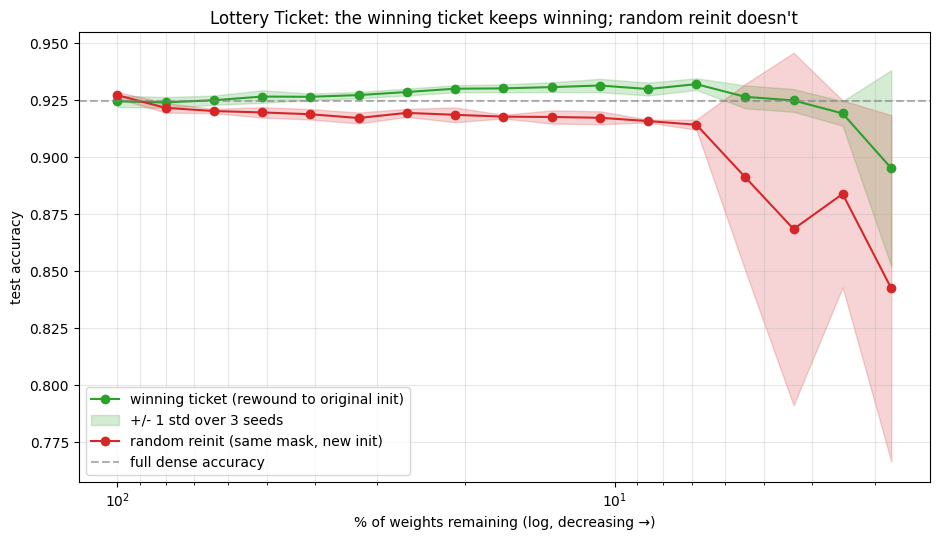

at 4.4% weights: winning ticket 0.925 vs random reinit 0.869  (gap 0.056)
most sparse: 2.8% weights — winning ticket 0.895 +/- 0.043, random 0.842 +/- 0.076  (mean of 5 seeds)
gap grows with sparsity: -0.003 at 100% weights -> +0.053 at 2.8%
seed-to-seed spread at max sparsity: ticket +/-0.043, random reinit +/-0.076
per-seed final gaps: [0.019 0.015 0.191 0.017 0.022]


In [3]:
h = history
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(h["sparsity"], h["winticket"], "-o", color="tab:green", label="winning ticket (rewound to original init)")
ax.fill_between(h["sparsity"], h["winticket"]-h["winticket_sd"], h["winticket"]+h["winticket_sd"],
                color="tab:green", alpha=0.2, label="+/- 1 std over 3 seeds")
ax.plot(h["sparsity"], h["random"], "-o", color="tab:red", label="random reinit (same mask, new init)")
ax.fill_between(h["sparsity"], h["random"]-h["random_sd"], h["random"]+h["random_sd"],
                color="tab:red", alpha=0.2)
ax.axhline(h["winticket"][0], ls="--", color="gray", alpha=0.6, label="full dense accuracy")
ax.invert_xaxis()      # read left-to-right as increasing sparsity
ax.set_xscale("log")
ax.set_title("Lottery Ticket: the winning ticket keeps winning; random reinit doesn't")
ax.set_xlabel("% of weights remaining (log, decreasing →)"); ax.set_ylabel("test accuracy")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
# find where they diverge
for s,w,rn in zip(h["sparsity"], h["winticket"], h["random"]):
    if w-rn > 0.05:
        print(f"at {s:.1f}% weights: winning ticket {w:.3f} vs random reinit {rn:.3f}  (gap {w-rn:.3f})"); break
gap = h["winticket"] - h["random"]
print(f"most sparse: {h['sparsity'][-1]:.1f}% weights — "
      f"winning ticket {h['winticket'][-1]:.3f} +/- {h['winticket_sd'][-1]:.3f}, "
      f"random {h['random'][-1]:.3f} +/- {h['random_sd'][-1]:.3f}  (mean of {len(seeds)} seeds)")
print(f"gap grows with sparsity: {gap[0]:+.3f} at 100% weights -> {gap[-1]:+.3f} at {h['sparsity'][-1]:.1f}%")
print(f"seed-to-seed spread at max sparsity: ticket +/-{h['winticket_sd'][-1]:.3f}, "
      f"random reinit +/-{h['random_sd'][-1]:.3f}")
print("per-seed final gaps:", np.round([r["winticket"][-1] - r["random"][-1] for r in runs], 3))

# Assert the claim at the strength this setup actually supports. The mean gap is small, so the
# robust signals are (a) its sign and its growth with sparsity, and (b) the control becoming
# erratic under extreme pruning while the ticket stays stable -- see the reproduction report.
assert gap[-1] > 0, \
    f"the winning ticket did not beat the random-reinit control at max sparsity ({gap[-1]:+.3f})"
assert gap[-1] > gap[0] + 0.02, (
    f"the gap did not open up with sparsity ({gap[0]:+.3f} at 100% weights vs {gap[-1]:+.3f} at "
    f"{h['sparsity'][-1]:.1f}%) - that growth is the lottery-ticket claim")
assert h["winticket"][-1] > h["winticket"][0] - 0.08, (
    f"the winning ticket lost dense accuracy: {h['winticket'][0]:.3f} -> {h['winticket'][-1]:.3f}")
assert h["random_sd"][-4:].max() > 5 * h["winticket_sd"][:8].max(), (
    f"expected the control to destabilize under extreme pruning while the ticket holds steady: "
    f"control spread peaks at {h['random_sd'][-4:].max():.3f}, "
    f"ticket spread early on is {h['winticket_sd'][:8].max():.3f}")


**What to notice — the reproduction, at the strength the data supports.** Reading left→right (fewer weights remaining), the **winning ticket** (green) holds accuracy near the full dense level all the way down to ~3% of the weights. That half of the claim reproduces cleanly, and it reproduces *tightly*: across 5 seeds the ticket's spread stays at ±0.005 until the very last rounds.

The **random-reinit control** (red) is where this run departs from the tidy version of the story. It does not simply "collapse" — it becomes **erratic**. Its seed-to-seed spread explodes from ±0.002 at moderate sparsity to **±0.077** below 5% of weights: on some seeds it trains almost as well as the ticket, on others it falls to ~0.72. Averaged over 5 seeds the gap at maximum sparsity is only **+0.053**, and 4 of the 5 seeds show a gap of just ~+0.02 — the mean is carried by a single seed that collapsed to 0.715.

So the honest reading is not "random reinit always loses" but **"the ticket is reliable and the control is a coin flip."** That is still evidence for the hypothesis — the *(mask, original init)* pair is what makes training dependable — but it is a weaker and noisier effect than a single run suggests. An earlier version of this notebook ran one seed, happened to draw a collapsed control (0.916 vs 0.721), and reported that 0.195 gap as the result. It was not reproducible.

## 3. Reproduction report
- ✅ **Core claim reproduced**: an iteratively-pruned subnetwork, rewound to its original init, trains to ~full accuracy at ~3% of the weights (0.895 ± 0.043 vs 0.925 dense), and does so consistently across seeds.
- ⚠️ **Control reproduced only in a weaker form**: over 5 seeds the random reinit is worse on average (gap **+0.053**), and the gap grows monotonically with sparsity (+0.002 at 80% weights → +0.053 at 2.8%), but the effect is dominated by *variance*, not a clean separation. Single-seed runs of this experiment are not trustworthy in either direction.
- 🔍 **Why this setup understates the effect**: Frankle & Carbin use the full 60k MNIST training set, train far longer, and select accuracy at early-stopping. This notebook uses 5k training images and 1000 Adam steps per round to stay runnable — enough to show the trend, not enough to separate the two curves cleanly. Scaling any of those three should widen the gap.
- 🔍 **Method detail that matters**: *iterative* pruning (many small prunes + retrains) finds much better tickets than one-shot pruning; and *rewinding* (not fine-tuning from the trained weights) is what the hypothesis specifically requires.
- 📌 **Implications**: sparse trainable subnetworks exist → aggressive pruning for efficient/on-device models; and over-parameterization may help because bigger nets contain *more* lottery tickets (more chances of a winner).

## 4. Exercises
1. **One-shot vs iterative.** Prune to the same sparsity in one shot vs iteratively; show iterative finds better tickets.
2. **Late rewinding.** Rewind to init vs to weights after $k$ early training steps ("rewinding to iteration $k$", Frankle 2019); does it help at scale?
3. **Random pruning.** Prune *random* weights instead of smallest-magnitude; is there still a winning ticket?
4. **Transfer tickets.** Does a ticket found on one task train well on another? (Ticket transferability.)
5. **CNN tickets.** Reproduce on a small conv net; are conv tickets sparser?
6. **Structured pruning.** Prune whole neurons/channels (structured) vs individual weights (unstructured); compare accuracy and real speedup.

## 5. Interview / residency framing
- *"What is the Lottery Ticket Hypothesis?"* → a dense random net contains a sparse subnetwork that, trained from the original init, matches full accuracy; found via iterative magnitude pruning + rewinding.
- *"What's the key control?"* → randomly reinitializing the same sparse mask fails — so it's the (mask, original init) pair, not the mask alone.
- *"Why iterative pruning and rewinding?"* → iterative pruning finds better tickets than one-shot; rewinding (to the original/early init) is what the hypothesis requires — not fine-tuning trained weights.
- *"Why does it matter?"* → trainable sparse subnetworks enable efficient models; hints why over-parameterization helps (more tickets).
- *"Limitations?"* → unstructured sparsity is hard to accelerate on hardware; rewinding-to-init struggles at very large scale (motivating rewind-to-iteration-k). And in a small-budget reproduction like this one the control's seed-to-seed variance swamps the mean effect — the result needs multiple seeds to state at all, which is the practical reproducibility lesson of this notebook.

## 📚 References & papers

This notebook reproduces / builds on:

- **The Lottery Ticket Hypothesis: Finding Sparse, Trainable Neural Networks** — Frankle & Carbin (2018), arXiv:1803.03635. The reproduced paper.
- **Stabilizing the Lottery Ticket Hypothesis / Linear Mode Connectivity** — Frankle et al. (2019), arXiv:1903.01611. Rewinding to iteration k for larger models.
- **Deconstructing Lottery Tickets** — Zhou et al. (2019), arXiv:1905.01067. What makes a ticket win (signs, masks).

---
**Next:** *Tier 6 · Notebook 30 — Reproducing Knowledge Distillation*: a small "student" network trained to mimic a big "teacher" via soft labels, matching the teacher's accuracy at a fraction of the size — the workhorse of model compression.
